### Import important libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statistics as stat
import seaborn as sns
import plotly.express as px
from bokeh.plotting import figure, show

### Import Data

In [2]:
pd.set_option('display.max_columns', None)
db = pd.read_csv('diabetic_EDA.csv')
copy = db.copy()
db.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type,discharge_disposition,admission_source,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,Unknown,Not Mapped,Physician Referral,1,Unknown,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,Emergency,Discharged to home,Emergency Room,3,Unknown,Unknown,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,African American,Female,[20-30),NaN,Emergency,Discharged to home,Emergency Room,2,Unknown,Unknown,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,Emergency,Discharged to home,Emergency Room,2,Unknown,Unknown,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,Emergency,Discharged to home,Emergency Room,1,Unknown,Unknown,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


### Perform descriptive statistical analysis for numerical features

In [3]:
db.describe()

,encounter_id,patient_nbr,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [4]:
# Drops administrative IDs and computes central tendency, skewness, and kurtosis
num_df = db.select_dtypes(include=[np.number]).drop(columns=['encounter_id', 'patient_nbr'], errors='ignore')
summary = num_df.describe().T
summary['skew'], summary['kurt'] = num_df.skew(), num_df.kurt()
print(summary.round(2))

                       count   mean    std  min   25%   50%   75%    max  \
time_in_hospital    101766.0   4.40   2.99  1.0   2.0   4.0   6.0   14.0   
num_lab_procedures  101766.0  43.10  19.67  1.0  31.0  44.0  57.0  132.0   
num_procedures      101766.0   1.34   1.71  0.0   0.0   1.0   2.0    6.0   
num_medications     101766.0  16.02   8.13  1.0  10.0  15.0  20.0   81.0   
number_outpatient   101766.0   0.37   1.27  0.0   0.0   0.0   0.0   42.0   
number_emergency    101766.0   0.20   0.93  0.0   0.0   0.0   0.0   76.0   
number_inpatient    101766.0   0.64   1.26  0.0   0.0   0.0   1.0   21.0   
number_diagnoses    101766.0   7.42   1.93  1.0   6.0   8.0   9.0   16.0   

                     skew     kurt  
time_in_hospital     1.13     0.85  
num_lab_procedures  -0.24    -0.25  
num_procedures       1.32     0.86  
num_medications      1.33     3.47  
number_outpatient    8.83   147.91  
number_emergency    22.86  1191.69  
number_inpatient     3.61    20.72  
number_diagnoses   

### Visualize the distribution of categorical features race and gender

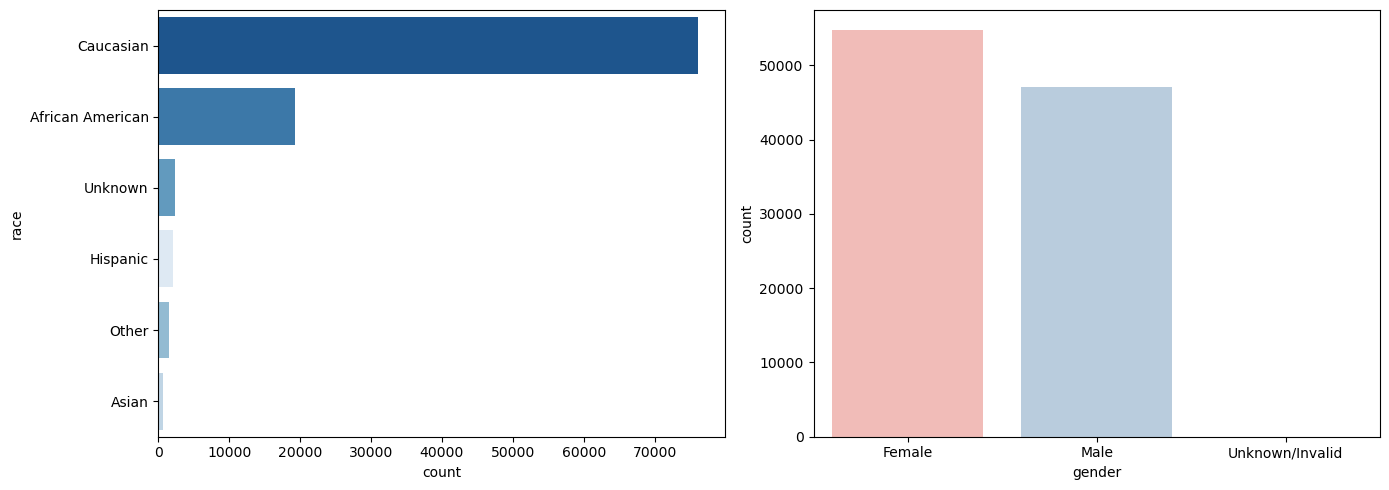

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=db, y='race', order=db['race'].value_counts().index, palette='Blues_r', hue='race', legend=False, ax=axes[0])
sns.countplot(data=db, x='gender', order=db['gender'].value_counts().index, palette='Pastel1', hue='gender', legend=False, ax=axes[1])
plt.tight_layout()
plt.savefig('demographics_distribution.png', dpi=300)

### Investigate correlations between numerical features

In [6]:
#num_df = db.select_dtypes(include=[np.number]).drop(columns=['encounter_id', 'patient_nbr'], errors='ignore')
#corr = num_df.corr()
#print("=======CORRELATION MATRIX =======")
#display(corr)
#fig, ax = plt.subplots(figsize=(8, 6))
#sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
#plt.tight_layout()
#plt.savefig('clinical_correlations.png', dpi=300)

======= CORRELATION MATRIX =======


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
time_in_hospital,1.000,0.318,0.191,0.466,-0.009,-0.010,0.074,0.220
num_lab_procedures,0.318,1.000,0.058,0.268,-0.008,-0.002,0.039,0.153
num_procedures,0.191,0.058,1.000,0.386,-0.025,-0.038,-0.066,0.074
num_medications,0.466,0.268,0.386,1.000,0.045,0.013,0.064,0.262
number_outpatient,-0.009,-0.008,-0.025,0.045,1.000,0.091,0.107,0.094
number_emergency,-0.010,-0.002,-0.038,0.013,0.091,1.000,0.267,0.056
number_inpatient,0.074,0.039,-0.066,0.064,0.107,0.267,1.000,0.105
number_diagnoses,0.220,0.153,0.074,0.262,0.094,0.056,0.105,1.000


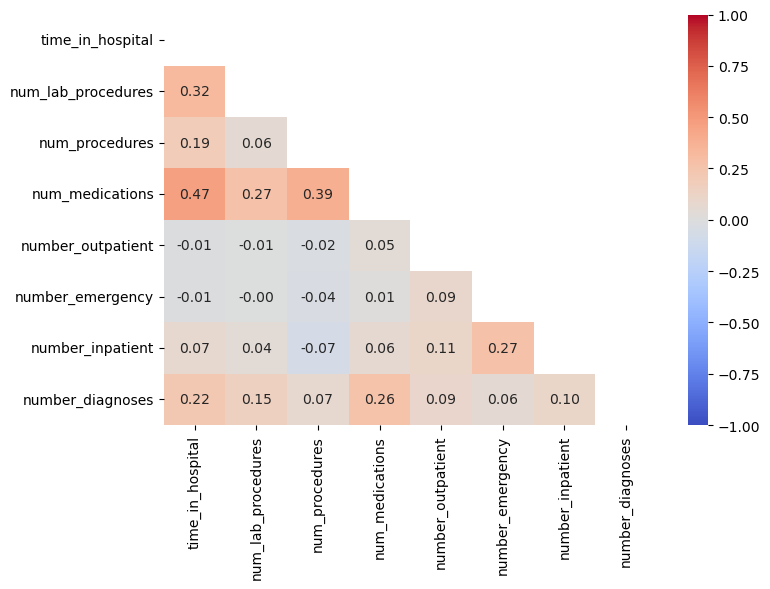

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Grab numeric columns and drop tracking keys
num_df = db.select_dtypes(include=[np.number]).drop(columns=['encounter_id', 'patient_nbr'], errors='ignore')
corr = num_df.corr()

print("======= CORRELATION MATRIX =======")
display(corr.round(3))

# 2. FIX: Generate the upper-triangle mask to eliminate symmetry noise
mask = np.triu(np.ones_like(corr, dtype=bool))

# 3. Setup and plot the chart frame
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr, 
    mask=mask,       # Now 'mask' is properly defined!
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    ax=ax
)

plt.tight_layout()
plt.savefig('clinical_correlations.png', dpi=300)
plt.show()            # Ensures the image draws cleanly on your dashboard screen

### Analyze the distribution of medication changes and total medications taken

======= MEDICATION CHANGE DISTRIBUTION =======


NameError: name 'change_counts' is not defined

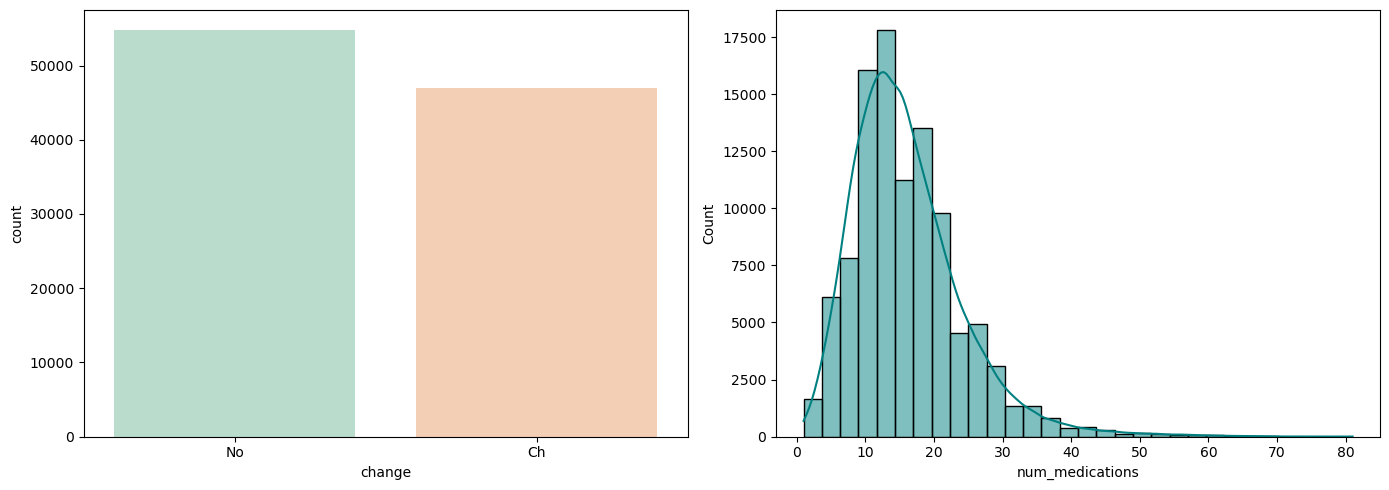

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=db, x='change', order=db['change'].value_counts().index, palette='Pastel2', hue='change', legend=False, ax=axes[0])
sns.histplot(data=db, x='num_medications', kde=True, bins=30, color='teal', ax=axes[1])
plt.tight_layout()
plt.savefig('medications_profile.png', dpi=300)
print("======= MEDICATION CHANGE DISTRIBUTION =======")
for idx in change_counts.index:
    print(f"Status '{idx}': {change_counts[idx]:,} encounters ({change_pct[idx]:.2f}%)")

print("\n======= TOTAL MEDICATIONS STATISTICAL SUMMARY =======")
print(med_stats.round(2))

### Examine the distribution of diagnoses categories

In [ ]:
def map_diag(c):
    c = str(c).split('.')[0]
    if c in ['?', ''] or pd.isna(c) or c.startswith(('V', 'E')) or not c.isdigit(): return 'Other'
    v = int(c)
    if 390 <= v <= 459 or v == 785: return 'Circulatory'
    if 460 <= v <= 519 or v == 786: return 'Respiratory'
    if 520 <= v <= 579 or v == 787: return 'Digestive'
    if v == 250: return 'Diabetes'
    if 800 <= v <= 999: return 'Injury'
    if 710 <= v <= 739: return 'Musculoskeletal'
    if 580 <= v <= 629 or v == 788: return 'Genitourinary'
    return 'Other'

db['diag_cat'] = db['diag_1'].apply(map_diag)
fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=db, y='diag_cat', order=db['diag_cat'].value_counts().index, palette='Spectral', hue='diag_cat', legend=False, ax=ax)
plt.tight_layout()
plt.savefig('diagnoses_distribution.png', dpi=300)

### Explore the distribution of patients across admission types, sources, and discharge dispositions

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
for i, col in enumerate(['admission_type', 'admission_source', 'discharge_disposition']):
    top_10 = db[col].astype(str).value_counts().head(10).index
    sns.countplot(data=db[db[col].astype(str).isin(top_10)], y=col, order=top_10, palette='viridis', hue=col, legend=False, ax=axes[i])
plt.tight_layout()
plt.savefig('administrative_flow.png', dpi=300)

### Identify and visualize any outliers in the dataset, especially in numerical features

In [ ]:
# 1. Define the clinical numerical columns
num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 
            'num_medications', 'number_outpatient', 'number_emergency', 
            'number_inpatient', 'number_diagnoses']

# 2. Compute Outlier Statistics
print("======= OUTLIER COUNTS USING IQR =======")
for col in num_cols:
    q1, q3 = db[col].quantile(0.25), db[col].quantile(0.75)
    iqr = q3 - q1
    outliers = db[(db[col] < (q1 - 1.5 * iqr)) | (db[col] > (q3 + 1.5 * iqr))]
    print(f"{col:<20} -> Outliers: {len(outliers):>6,} ({len(outliers)/len(db)*100:.2f}%)")

# 3. Create a 2x4 Grid of Boxplots
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=db, y=col, ax=axes[i], color='salmon')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.savefig('numerical_outliers_boxplots.png', dpi=300)